# IPL Data Analysis & Insights (2008–2025)

## Objective
To analyze IPL data and extract insights on team performance, player statistics, and match trends.

In [2]:
import pandas as pd

df=pd.read_csv("D:\BESANT data science master program\Python\project DA\matches.csv")
df.head()

,match_id,season,match_number,stage,date,venue,city,team1,team2,toss_winner,...,second_innings_wickets,second_innings_overs,result,winner,win_by,win_margin,player_of_match,umpire1,umpire2,is_day_night
0,M0001,2008,1,League,2008-03-13,Punjab Cricket Association Stadium,Mohali,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,...,8,15.4,normal,Kings XI Punjab,runs,81,Moeen Taylor,Aleem Dar,Marais Erasmus,False
1,M0002,2008,2,League,2008-03-14,Greenfield Intl Stadium,Thiruvananthapuram,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,...,3,18.6,normal,Kolkata Knight Riders,wickets,7,Shai Amla,Michael Gough,Simon Taufel,True
2,M0003,2008,3,League,2008-03-15,M. A. Chidambaram Stadium,Chennai,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,2,19.0,normal,Chennai Super Kings,runs,81,Lungi Warner,KN Ananthapadmanabhan,Michael Gough,True
3,M0004,2008,4,League,2008-03-16,DY Patil Stadium,Navi Mumbai,Chennai Super Kings,Deccan Chargers,Chennai Super Kings,...,1,17.4,normal,Deccan Chargers,runs,7,Denesh Cummins,Kumar Dharmasena,Simon Taufel,False
4,M0005,2008,5,League,2008-03-17,Sawai Mansingh Stadium,Jaipur,Rajasthan Royals,Kolkata Knight Riders,Kolkata Knight Riders,...,4,15.4,normal,Kolkata Knight Riders,runs,31,Ollie Siraj,Sundaram Ravi,KN Ananthapadmanabhan,False


In [3]:
# CLEANING DATA  

df.isnull().sum()

match_id                   0
season                     0
match_number               0
stage                      0
date                       0
venue                      0
city                       0
team1                      0
team2                      0
toss_winner                0
toss_decision              0
first_innings_score        0
first_innings_wickets      0
first_innings_overs        0
second_innings_score       0
second_innings_wickets     0
second_innings_overs       0
result                     0
winner                    26
win_by                    26
win_margin                 0
player_of_match            0
umpire1                    0
umpire2                    0
is_day_night               0
dtype: int64

In [4]:
# Handle missing values 

df = df.dropna(subset=['winner'])

In [5]:
df.isnull().sum()

match_id                  0
season                    0
match_number              0
stage                     0
date                      0
venue                     0
city                      0
team1                     0
team2                     0
toss_winner               0
toss_decision             0
first_innings_score       0
first_innings_wickets     0
first_innings_overs       0
second_innings_score      0
second_innings_wickets    0
second_innings_overs      0
result                    0
winner                    0
win_by                    0
win_margin                0
player_of_match           0
umpire1                   0
umpire2                   0
is_day_night              0
dtype: int64

    BASIC ANALYSIS 

In [11]:
# 1 Total Number Of Teams

import numpy as np

teams = np.unique(np.concatenate((df['team1'], df['team2'])))
print(len(teams),'Teams')


17 Teams


In [12]:
# 2 Total Matches Played by Teams 

matches_played = pd.concat([df['team1'], df['team2']]).value_counts()
matches_played


Royal Challengers Bangalore    278
Mumbai Indians                 271
Kolkata Knight Riders          250
Chennai Super Kings            238
Rajasthan Royals               221
Kings XI Punjab                183
Sunrisers Hyderabad            182
Delhi Daredevils               159
Delhi Capitals                 100
Punjab Kings                    85
Deccan Chargers                 67
Lucknow Super Giants            53
Gujarat Titans                  48
Pune Warriors India             47
Gujarat Lions                   35
Rising Pune Supergiant          34
Kochi Tuskers Kerala            13
Name: count, dtype: int64

In [13]:
# 3. Matches Won By Teams 

matches_won = df['winner'].value_counts()
matches_won


winner
Royal Challengers Bangalore    144
Mumbai Indians                 130
Chennai Super Kings            129
Kolkata Knight Riders          128
Rajasthan Royals                99
Kings XI Punjab                 96
Sunrisers Hyderabad             93
Delhi Daredevils                73
Delhi Capitals                  49
Punjab Kings                    47
Deccan Chargers                 31
Pune Warriors India             27
Lucknow Super Giants            22
Gujarat Lions                   20
Rising Pune Supergiant          19
Gujarat Titans                  19
Kochi Tuskers Kerala             6
Name: count, dtype: int64

# 1 Team Performance Analysis

In [14]:

# 1.1 Total Wins by Team
win_percentage = (matches_won / matches_played) * 100
win_percentage.sort_values(ascending=False)

Pune Warriors India            57.446809
Gujarat Lions                  57.142857
Rising Pune Supergiant         55.882353
Punjab Kings                   55.294118
Chennai Super Kings            54.201681
Kings XI Punjab                52.459016
Royal Challengers Bangalore    51.798561
Kolkata Knight Riders          51.200000
Sunrisers Hyderabad            51.098901
Delhi Capitals                 49.000000
Mumbai Indians                 47.970480
Deccan Chargers                46.268657
Kochi Tuskers Kerala           46.153846
Delhi Daredevils               45.911950
Rajasthan Royals               44.796380
Lucknow Super Giants           41.509434
Gujarat Titans                 39.583333
Name: count, dtype: float64

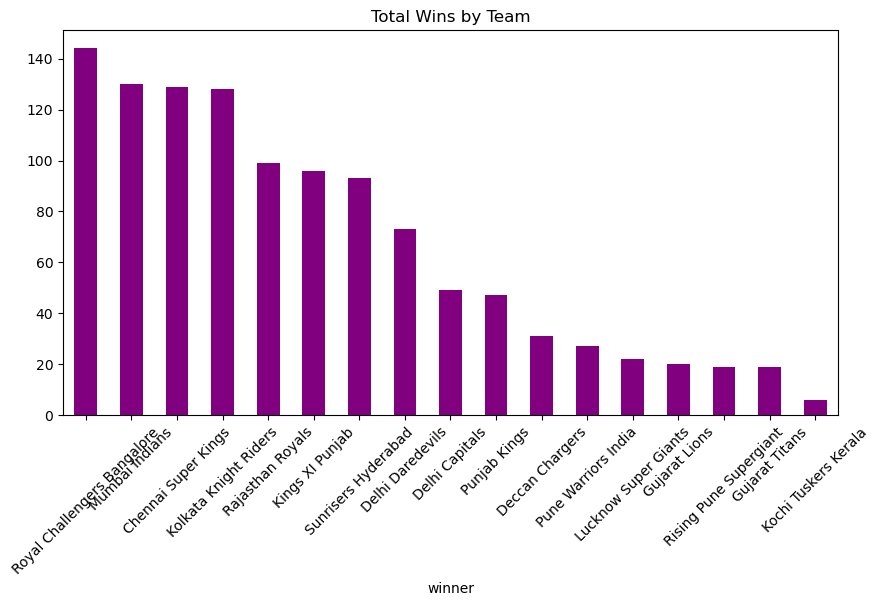

In [19]:
# 1.1 Total Wins by Team

# Total Wins
import matplotlib.pyplot as plt
matches_won.plot(kind='bar', figsize=(10,5),color='purple')
plt.title('Total Wins by Team')
plt.xticks(rotation=45)
plt.show()

[This graph shows total matches won by each team. However, it does not consider how many matches each team played.]

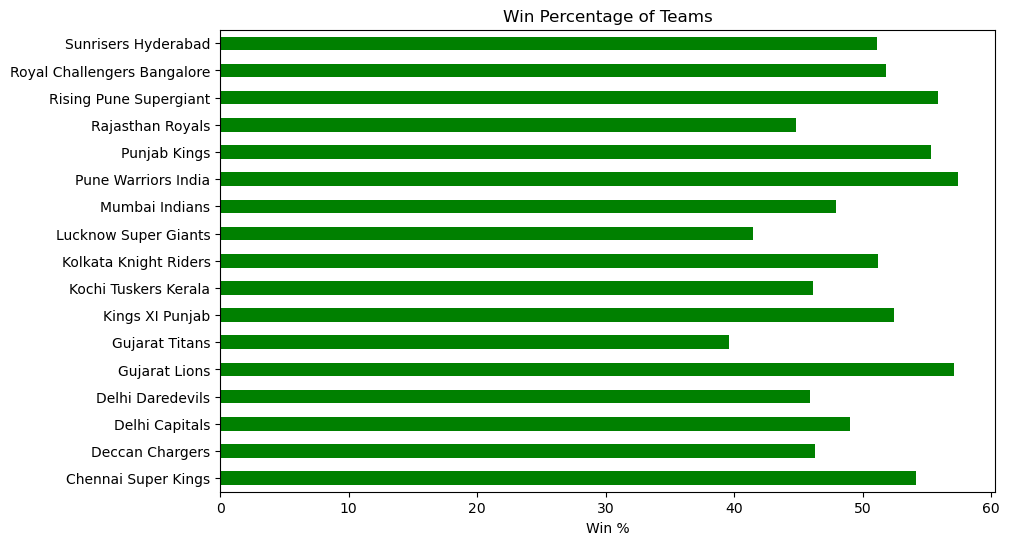

In [22]:
# 1.2 Win Percentage Analysis

# Win Percentage
win_percentage.plot(kind='barh', figsize=(10,6), color='green')
plt.title('Win Percentage of Teams')
plt.xlabel('Win %')
plt.show()

[This graph shows team efficiency. Teams with higher win percentage are more consistent performers.]

# 2 Toss Impact Analysis

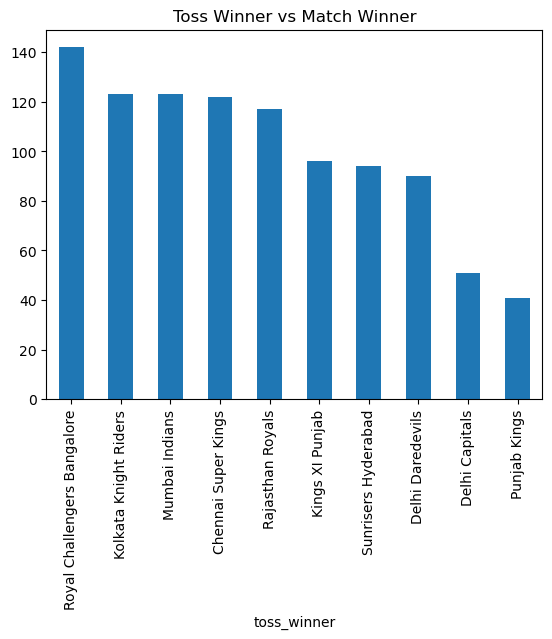

In [44]:
# 2.1 Toss Winner vs Match Winner

# Toss Impact Analysis
toss_vs_win = pd.crosstab(df['toss_winner'], df['winner'])

df['toss_winner'].value_counts().head(10).plot(kind='bar')
plt.title('Toss Winner vs Match Winner')
plt.show()


[This analysis helps understand whether winning the toss gives an advantage in winning the match.]

# 3.Venue Analysis

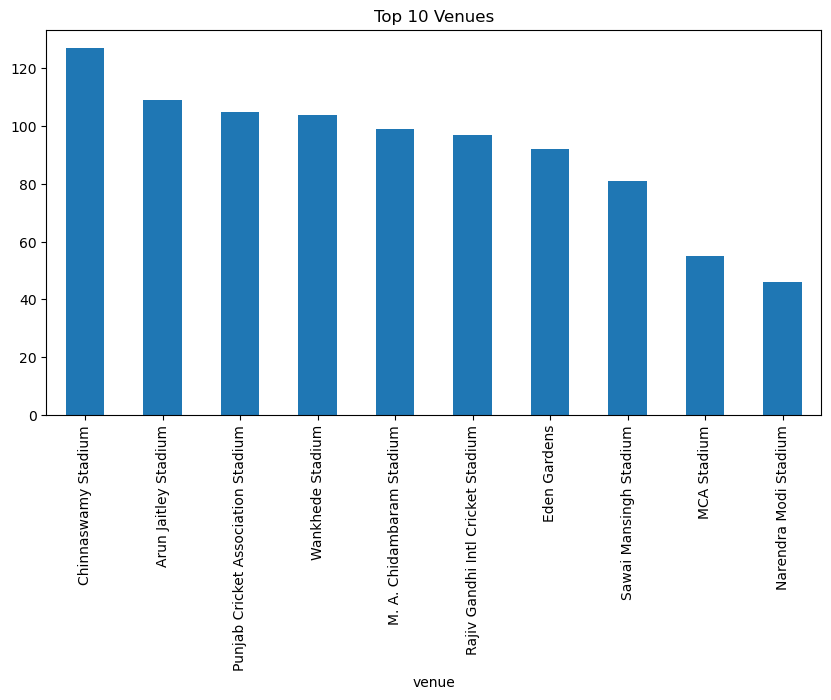

In [25]:
# 3.1 Top Venues

# Top Venues
df['venue'].value_counts().head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Venues')
plt.show()

[This shows which stadiums host the most IPL matches.]

# 4 Matches Played Analysis

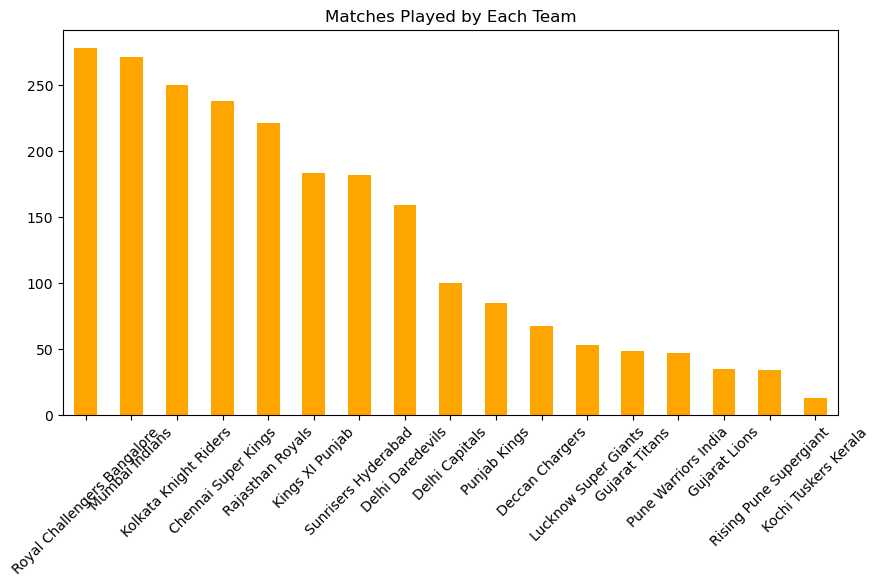

In [26]:
# 4.1 Matches Played by Each Team

# Matches Played
matches_played.plot(kind='bar', figsize=(10,5), color='orange')
plt.title('Matches Played by Each Team')
plt.xticks(rotation=45)
plt.show()

[This shows how frequently each team has participated in IPL matches.]

# 5. Final Insights 

Final Insights from IPL Data Analysis  
 🔹 Team Performance
-->Mumbai Indians and Chennai Super Kings are among the most successful teams in IPL history based on total wins.
-->However, win percentage reveals true performance efficiency, highlighting consistently strong teams.

 🔹 Win Percentage Insight
-->Teams with fewer matches but higher win percentage show better consistency.
-->Some teams may have high total wins but lower efficiency due to more matches played.

  🔹 Toss Impact
-->Winning the toss provides a slight advantage but does not guarantee match victory.
-->Match outcome depends on multiple factors like team strength and conditions.

  🔹 Venue Analysis
-->Certain stadiums host more matches, indicating their importance in IPL scheduling.
-->Teams may perform differently depending on venue conditions.

  🔹 Overall Conclusion
-->IPL performance depends on multiple factors including team strength, venue, and match conditions.
-->Data analysis helps uncover patterns but cannot fully predict match outcomes.

# 6.Top Batsmen Analysis

##  Player-level results may not reflect actual IPL records due to dataset inconsistencies.

In [27]:
# 6.1 Load deliveries dataset

deliveries = pd.read_csv("D:\BESANT data science master program\Python\project DA\deliveries.csv")
deliveries.head()

,delivery_id,match_id,innings,over,ball,batting_team,bowling_team,striker,non_striker,bowler,batsman_runs,extra_runs,total_runs,extra_type,is_wicket,dismissal_type,dismissed_player,fielder
0,D0000001,M0001,1,1,1,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
1,D0000002,M0001,1,1,2,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,4,0,4,NaN,False,NaN,NaN,NaN
2,D0000003,M0001,1,1,3,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,0,0,0,NaN,True,caught,Yuzvendra Kumar,Aiden Anderson
3,D0000004,M0001,1,1,4,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
4,D0000005,M0001,1,1,5,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,6,1,7,no-ball,False,NaN,NaN,NaN


In [29]:
deliveries.columns

Index(['delivery_id', 'match_id', 'innings', 'over', 'ball', 'batting_team',
       'bowling_team', 'striker', 'non_striker', 'bowler', 'batsman_runs',
       'extra_runs', 'total_runs', 'extra_type', 'is_wicket', 'dismissal_type',
       'dismissed_player', 'fielder'],
      dtype='object')

In [32]:
deliveries.columns
deliveries.head()

,delivery_id,match_id,innings,over,ball,batting_team,bowling_team,striker,non_striker,bowler,batsman_runs,extra_runs,total_runs,extra_type,is_wicket,dismissal_type,dismissed_player,fielder
0,D0000001,M0001,1,1,1,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
1,D0000002,M0001,1,1,2,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,4,0,4,NaN,False,NaN,NaN,NaN
2,D0000003,M0001,1,1,3,Kings XI Punjab,Royal Challengers Bangalore,Yuzvendra Kumar,Harry Khan,Wriddhiman Chahar,0,0,0,NaN,True,caught,Yuzvendra Kumar,Aiden Anderson
3,D0000004,M0001,1,1,4,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,2,0,2,NaN,False,NaN,NaN,NaN
4,D0000005,M0001,1,1,5,Kings XI Punjab,Royal Challengers Bangalore,Harry Khan,Adil Taylor,Wriddhiman Chahar,6,1,7,no-ball,False,NaN,NaN,NaN


In [33]:
#6.2 Top Run Scorers

top_batsmen = deliveries.groupby('striker')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batsmen

striker
Ajinkya Saha        1043
Liam Ali            1014
Faisal Akhtar       1001
Deepak Root          994
Fazalhaq Rizwan      938
Sunil Cummins        926
Glenn Topley         920
Nicholas Rashid      907
Manish Pretorius     901
Ajinkya Agarwal      895
Name: batsman_runs, dtype: int64

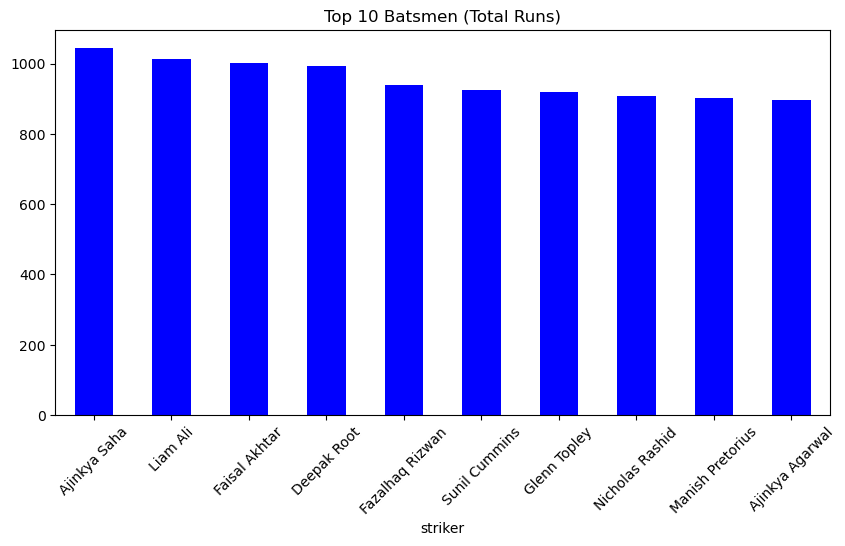

In [36]:
top_batsmen.plot(kind='bar', figsize=(10,5), color='blue')
plt.title('Top 10 Batsmen (Total Runs)')
plt.xticks(rotation=45)
plt.show()

[This shows the top run-scoring players in IPL history based on total runs.]

In [34]:
deliveries['match_id'].nunique()

1158

In [35]:
deliveries['striker'].unique()[:20]

array(['Yuzvendra Kumar', 'Harry Khan', 'Devdutt Agarwal', 'AB Ashraf',
       'Shoaib Amir', 'Najibullah Ashraf', 'Liam Southee',
       'Shardul Ashwin', 'Devdutt Boult', 'Hashim Gayle',
       'Yuzvendra Curran', 'Steve Iyer', 'Rohit Shami',
       'Suryakumar Shami', 'AB Buttler', 'Stuart Thakur',
       'Nicholas Archer', 'Nicholas Rashid', 'Glenn Topley',
       'Fazalhaq Rizwan'], dtype=object)

In [39]:
# 3 Top Bowlers 
top_bowlers = deliveries[deliveries['is_wicket'] == 1]['bowler'].value_counts().head(10)
top_bowlers


bowler
Naveen Stubbs             27
Andre Livingstone         26
Rassie Rizwan             25
Dinesh Azam               25
Quinton van der Dussen    24
Denesh Cummins            24
Rohit Livingstone         24
Najibullah Ngidi          23
Jofra Pandey              23
Kieron Pope               23
Name: count, dtype: int64

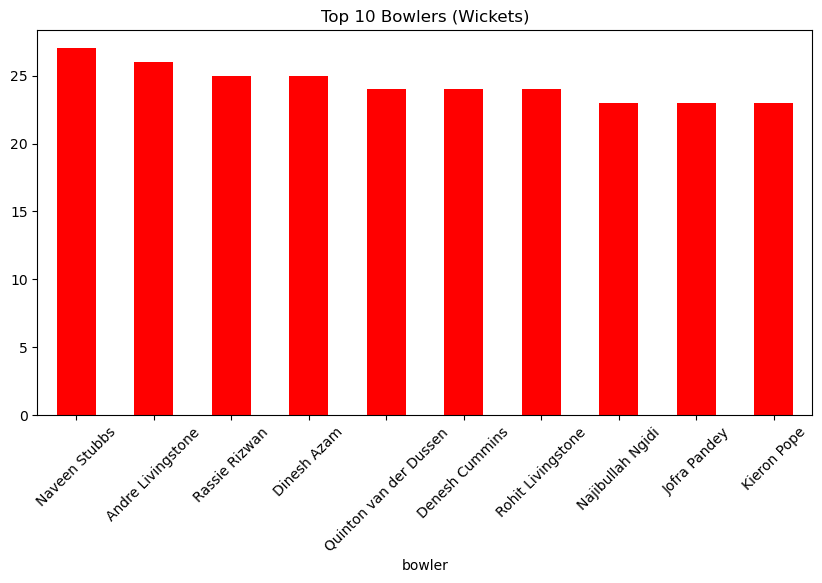

In [40]:
top_bowlers.plot(kind='bar', figsize=(10,5), color='red')
plt.title('Top 10 Bowlers (Wickets)')
plt.xticks(rotation=45)
plt.show()

[This shows the bowlers with highest wicket-taking performance.]

In [42]:
# 4  Strike Rate 

batsman_stats = deliveries.groupby('striker').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
})

batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['ball']) * 100

batsman_stats.sort_values(by='strike_rate', ascending=False).head(10)

,batsman_runs,ball,strike_rate
striker,,,
Mayank Padikkal,673,262,256.870229
Rilee Wood,269,105,256.190476
Naveen Stubbs,329,130,253.076923
Dwayne Conway,764,302,252.980132
Shadab Ali,447,177,252.542373
James Afridi,265,105,252.380952
Faf Chahar,729,292,249.657534
Faheem Tahir,300,121,247.933884
Shreyas Akhtar,492,199,247.236181


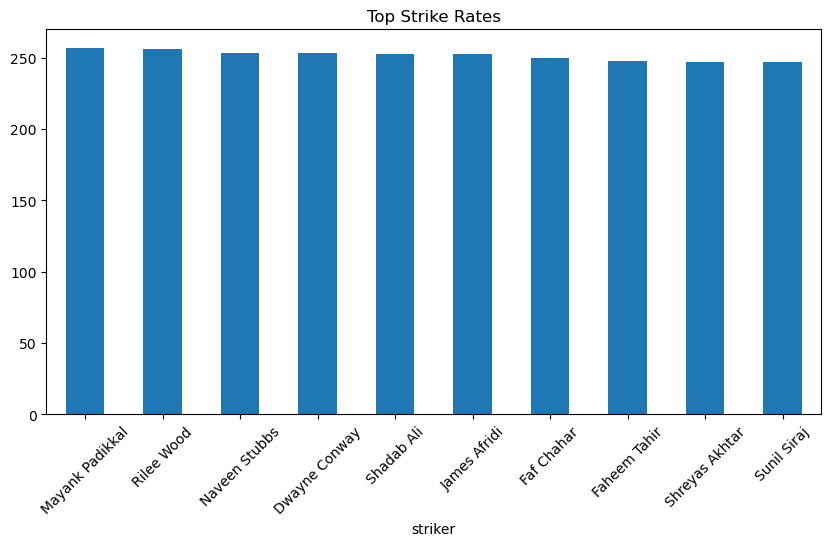

In [43]:
batsman_stats.sort_values(by='strike_rate', ascending=False).head(10)['strike_rate'].plot(kind='bar', figsize=(10,5))
plt.title('Top Strike Rates')
plt.xticks(rotation=45)
plt.show()

[Strike rate indicates how fast a player scores runs.]

## 🧹 Data Quality Observations

- The dataset contains inconsistencies in player names.
- Some player names appear incorrect or merged (e.g., "Hashim Gayle", "Steve Iyer").
- These issues can affect the accuracy of player-level analysis.

### ⚠️ Impact:
- Top batsman and bowler results may not reflect real IPL records.
- Analysis based on incorrect names may lead to misleading insights.

### ✅ Conclusion:
- Proper data cleaning is required before performing production-level analytics.
- Despite these issues, overall team-level analysis remains valid.